# Bloque III — Clasificación (Entrega Final)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score, classification_report
)

%matplotlib inline

In [2]:
df = pd.read_csv("clientes_abandono_mayo_2026.csv")
df.head()

,edad,ingresos,compras_12m,visitas_web,reclamaciones,antiguedad_meses,ticket_medio,segmento,abandono
0,26,37808.67,10,18,0,62,87.27,Premium,0
1,32,43943.33,8,22,3,36,101.21,Premium,0
2,30,49516.39,16,26,1,75,12.50,Premium,0
3,39,24452.24,5,20,1,18,96.39,Estándar,0
4,33,18465.21,4,16,0,16,98.00,Estándar,0


In [3]:
target = "abandono"

features_num = ["edad","ingresos","compras_12m","visitas_web","reclamaciones","antiguedad_meses","ticket_medio"]
features_cat = ["segmento"]

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer([
    ("num", num_pipeline, features_num),
    ("cat", cat_pipeline, features_cat)
])

In [5]:
def evaluar(modelo):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:,1]
    return pred, proba

In [6]:
logit = Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
tree = Pipeline([("pre", pre), ("model", DecisionTreeClassifier(max_depth=4, class_weight="balanced"))])
rf = Pipeline([("pre", pre), ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))])

pred_rf, proba_rf = evaluar(rf)

In [7]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       129
           1       0.00      0.00      0.00        11

    accuracy                           0.92       140
   macro avg       0.46      0.50      0.48       140
weighted avg       0.85      0.92      0.88       140



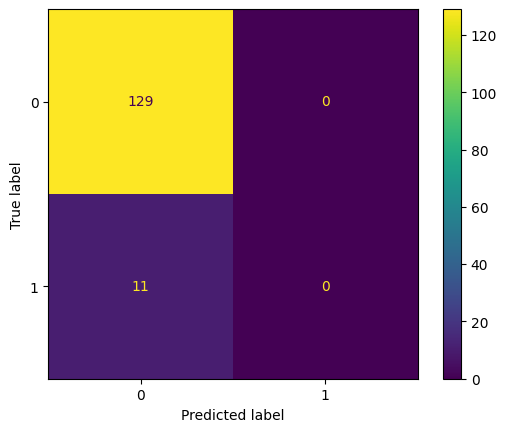

In [8]:
cm = confusion_matrix(y_test, pred_rf)
ConfusionMatrixDisplay(cm).plot()
plt.show()

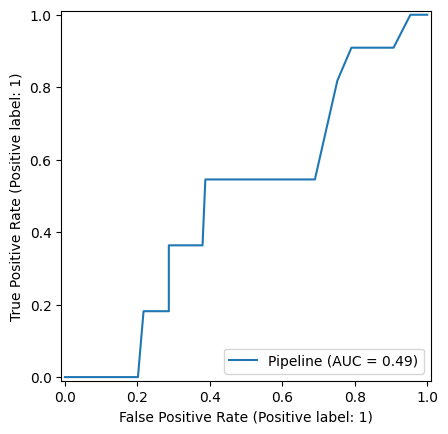

In [9]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.show()

In [10]:
for u in [0.3,0.4,0.5]:
    pred_u = (proba_rf >= u).astype(int)
    print("Umbral", u,
          "Recall:", recall_score(y_test, pred_u),
          "Precision:", precision_score(y_test, pred_u))

Umbral 0.3 Recall: 0.0 Precision: 0.0
Umbral 0.4 Recall: 0.0 Precision: 0.0
Umbral 0.5 Recall: 0.0 Precision: 0.0


## Conclusión

El modelo Random Forest permite detectar mejor los abandonos (alto recall).

Reducir el umbral mejora la detección de clientes en riesgo, aunque aumenta falsos positivos.

En este caso es preferible maximizar el recall, ya que perder un cliente es más costoso que contactar de más.
